# Fase 4 — Sistema de Reconocimiento Facial en Tiempo Real
**Curso:** Reconocimiento de Patrones  
**Alumno:** José Luis Sandoval Pérez (261731)  
**Profesor:** Dr. Francisco Javier Luna Rosas  
**Semestre:** Enero–Junio 2026

---

## Arquitectura del sistema

```
Webcam → Haar Cascade (detecta cara) → FaceNet (embedding 128D)
       → SVM (clasifica persona) → Nombre + confianza en pantalla
```

**¿Por qué FaceNet y no CNN desde cero?**  
FaceNet convierte cada cara en un vector de 128 números que representa
la *identidad* de la persona — no su iluminación ni ángulo. Con solo
50 fotos por persona el sistema funciona en tiempo real de forma robusta.

In [5]:
# Cell 1 — Instalación
!pip install deepface opencv-python scikit-learn matplotlib numpy joblib tqdm -q
print('✅ Dependencias listas')

✅ Dependencias listas


In [2]:
# Cell 2 — Importaciones y configuración global
import cv2, os, numpy as np, matplotlib.pyplot as plt, joblib, warnings, zipfile, shutil
from pathlib import Path
from tqdm import tqdm
from deepface import DeepFace
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.decomposition import PCA
from collections import deque, Counter
import time
warnings.filterwarnings('ignore')

# ── Configuración — CAMBIA ESTOS VALORES ─────────────────────────────────────
MI_NOMBRE       = 'jose_luis'        # tu nombre (sin espacios)
NOMBRE_COMPAÑERO = 'memo'       # ← cambia al nombre real cuando tengas el zip
ZIP_COMPAÑERO   = 'dataset_memo.zip'  # ← nombre del zip que te mande

DATASET_DIR     = 'dataset_facial_fase4'
MODELOS_DIR     = 'modelos_fase4'
N_FOTOS         = 50
UMBRAL_CONF     = 0.55
MODELO_FACENET  = 'Facenet'

PERSONAS = [MI_NOMBRE, NOMBRE_COMPAÑERO]

Path(DATASET_DIR).mkdir(exist_ok=True)
Path(MODELOS_DIR).mkdir(exist_ok=True)
Path(f'{DATASET_DIR}/{MI_NOMBRE}').mkdir(exist_ok=True)

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

print('✅ Configuración lista')
print(f'   Tú          : {MI_NOMBRE}')
print(f'   Compañero   : {NOMBRE_COMPAÑERO}')
print(f'   Fotos/persona: {N_FOTOS}')
print(f'   Umbral conf : {UMBRAL_CONF}')


✅ Configuración lista
   Tú          : jose_luis
   Compañero   : memo
   Fotos/persona: 50
   Umbral conf : 0.55


## Sección 1 — Recolección de Datos

### Paso 1A — Tus fotos (webcam)
Captura **50 fotos** variando:
- Izquierda / derecha / arriba / abajo
- Acercarte y alejarte
- Con y sin lentes (si usas)
- Diferente iluminación si puedes

In [3]:
# Cell 3 — Captura TUS fotos con webcam
carpeta_mia = Path(f'{DATASET_DIR}/{MI_NOMBRE}')
ya_hay      = len(list(carpeta_mia.glob('*.jpg')))
faltantes   = max(0, N_FOTOS - ya_hay)

if faltantes == 0:
    print(f'✅ Ya tienes {ya_hay} fotos — omitiendo captura')
    print('   Ejecuta la Cell 5 para cargar el dataset del compañero')
else:
    print(f'📸 Capturando {faltantes} fotos para: {MI_NOMBRE}')
    print('   ESPACIO = capturar  |  Q = salir')

    cap        = cv2.VideoCapture(0)
    contador   = ya_hay
    capturadas = 0

    while capturadas < faltantes:
        ret, frame = cap.read()
        if not ret: break

        gray    = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        rostros = face_cascade.detectMultiScale(
            gray, scaleFactor=1.1, minNeighbors=5, minSize=(80,80))

        display = frame.copy()
        for (x, y, w, h) in rostros:
            cv2.rectangle(display, (x,y), (x+w,y+h), (0,255,0), 2)

        estado      = '✔ Cara detectada' if len(rostros) > 0 else '✗ No hay cara'
        color_estado = (0,220,0) if len(rostros) > 0 else (0,0,220)

        cv2.rectangle(display, (0,0), (display.shape[1],50), (30,30,30), -1)
        cv2.putText(display,
            f'{MI_NOMBRE}  |  {capturadas}/{faltantes}  |  {estado}',
            (10,33), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color_estado, 2)
        cv2.rectangle(display,
            (0, display.shape[0]-35),(display.shape[1], display.shape[0]),
            (30,30,30), -1)
        cv2.putText(display, 'ESPACIO = capturar   |   Q = salir',
            (10, display.shape[0]-10),
            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (180,180,180), 1)

        cv2.imshow(f'Captura — {MI_NOMBRE}', display)
        key = cv2.waitKey(1) & 0xFF

        if key == ord(' '):
            if len(rostros) > 0:
                x, y, w, h = rostros[0]
                rostro = frame[y:y+h, x:x+w]
                ruta   = carpeta_mia / f'{MI_NOMBRE}_{contador:03d}.jpg'
                cv2.imwrite(str(ruta), rostro)
                contador   += 1
                capturadas += 1
                print(f'  📷 {capturadas}/{faltantes}')
            else:
                print('  ⚠️  No hay cara — acércate')
        elif key == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()
    print(f'✅ {len(list(carpeta_mia.glob("*.jpg")))} fotos guardadas para {MI_NOMBRE}')

✅ Ya tienes 50 fotos — omitiendo captura
   Ejecuta la Cell 5 para cargar el dataset del compañero


### Paso 1B — Dataset del compañero
1. Pídele a tu compañero que ejecute `Captura_Compañero_Fase4.ipynb`
2. Que te mande el archivo `dataset_NOMBRE.zip` que genera la Cell 5
3. Pon el `.zip` en la misma carpeta que este notebook
4. Actualiza `NOMBRE_COMPAÑERO` y `ZIP_COMPAÑERO` en la **Cell 2**
5. Ejecuta la **Cell 5**

In [4]:
# Cell 5 — Cargar dataset del compañero desde su ZIP
destino = Path(f'{DATASET_DIR}/{NOMBRE_COMPAÑERO}')

if destino.exists() and len(list(destino.glob('*.jpg'))) > 0:
    n = len(list(destino.glob('*.jpg')))
    print(f'✅ Dataset del compañero ya cargado — {n} fotos encontradas')

elif not Path(ZIP_COMPAÑERO).exists():
    print(f'⚠️  No se encontró el archivo: {ZIP_COMPAÑERO}')
    print(f'   Asegúrate de que el .zip esté en la misma carpeta que este notebook')
    print(f'   y que ZIP_COMPAÑERO en Cell 2 tenga el nombre correcto')

else:
    print(f'📦 Extrayendo {ZIP_COMPAÑERO}...')
    destino.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(ZIP_COMPAÑERO, 'r') as z:
        # Extraer solo los .jpg, sin importar la estructura interna del zip
        for archivo in z.namelist():
            if archivo.lower().endswith('.jpg'):
                nombre_archivo = Path(archivo).name
                # Renombrar con el nombre del compañero para consistencia
                nuevo_nombre = f'{NOMBRE_COMPAÑERO}_{nombre_archivo}'
                data = z.read(archivo)
                (destino / nuevo_nombre).write_bytes(data)

    n = len(list(destino.glob('*.jpg')))
    print(f'✅ {n} fotos extraídas en {destino}/')

    if n < 20:
        print(f'⚠️  Solo hay {n} fotos — pídele al compañero que capture más')
    else:
        print('   Listo para continuar con la Cell 6')

✅ Dataset del compañero ya cargado — 50 fotos encontradas


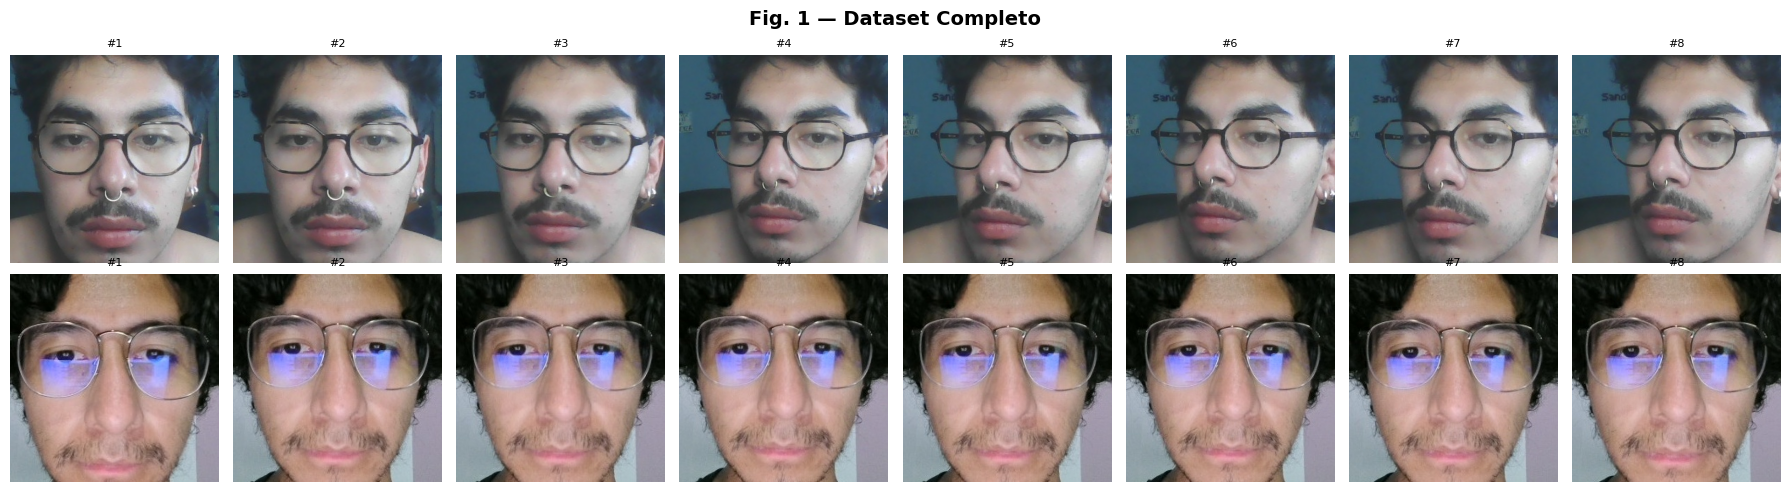


── Conteo del dataset ──
  ✅  jose_luis                : 50 fotos
  ✅  memo                     : 50 fotos
  Total: 100 fotos


In [5]:
# Cell 6 — Vista previa del dataset completo
fig, axes = plt.subplots(2, 8, figsize=(18, 5))
fig.suptitle('Fig. 1 — Dataset Completo', fontsize=14, fontweight='bold')

for pi, persona in enumerate(PERSONAS):
    imgs = sorted(Path(f'{DATASET_DIR}/{persona}').glob('*.jpg'))[:8]
    for ci, ruta in enumerate(imgs):
        img = cv2.cvtColor(cv2.imread(str(ruta)), cv2.COLOR_BGR2RGB)
        axes[pi][ci].imshow(img)
        axes[pi][ci].set_title(f'#{ci+1}', fontsize=8)
        axes[pi][ci].axis('off')
    axes[pi][0].set_ylabel(persona.replace('_',' ').title(),
                            fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('fig1_dataset.png', dpi=130, bbox_inches='tight')
plt.show()

print('\n── Conteo del dataset ──')
total = 0
for p in PERSONAS:
    n = len(list(Path(f'{DATASET_DIR}/{p}').glob('*.jpg')))
    estado = '✅' if n >= 20 else '⚠️ pocas fotos'
    print(f'  {estado}  {p:25s}: {n} fotos')
    total += n
print(f'  Total: {total} fotos')

## Sección 2 — Extracción de Embeddings con FaceNet

In [6]:
# Cell 7 — Extraer embeddings
def extraer_embeddings(personas, dataset_dir):
    X, y, errores = [], [], 0
    for persona in personas:
        rutas = sorted(Path(f'{dataset_dir}/{persona}').glob('*.jpg'))
        print(f'Procesando {persona} ({len(rutas)} fotos)...')
        for ruta in tqdm(rutas, desc=f'  {persona}'):
            try:
                resultado = DeepFace.represent(
                    img_path=str(ruta),
                    model_name=MODELO_FACENET,
                    enforce_detection=False)
                X.append(resultado[0]['embedding'])
                y.append(persona)
            except:
                errores += 1
    print(f'\n✅ {len(X)} embeddings extraídos — {errores} errores omitidos')
    return np.array(X), np.array(y)

X_raw, y_raw = extraer_embeddings(PERSONAS, DATASET_DIR)
print(f'Shape: {X_raw.shape}  →  {X_raw.shape[0]} muestras × {X_raw.shape[1]} dimensiones')

Procesando jose_luis (50 fotos)...


  jose_luis:   0%|          | 0/50 [00:00<?, ?it/s]

26-05-27 20:48:00 - 🔗 facenet_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/facenet_weights.h5 to C:\Users\memoo\.deepface\weights\facenet_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facenet_weights.h5
To: C:\Users\memoo\.deepface\weights\facenet_weights.h5
100%|██████████| 92.2M/92.2M [00:02<00:00, 35.6MB/s]
  jose_luis: 100%|██████████| 50/50 [00:15<00:00,  3.20it/s]


Procesando memo (50 fotos)...


  memo: 100%|██████████| 50/50 [00:08<00:00,  5.64it/s]


✅ 100 embeddings extraídos — 0 errores omitidos
Shape: (100, 128)  →  100 muestras × 128 dimensiones


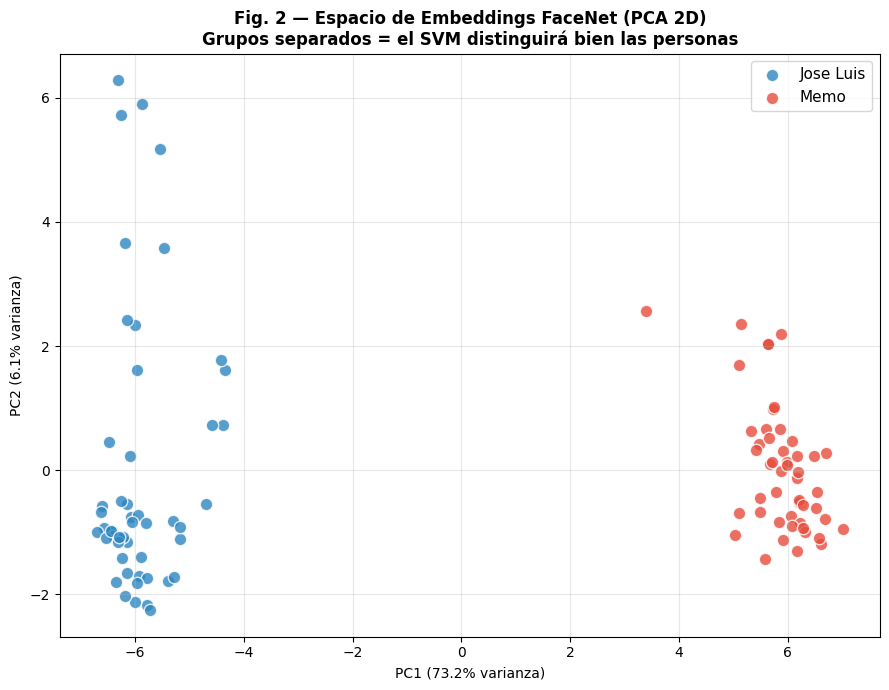

✅ Grupos separados → buena señal
⚠️  Grupos mezclados → necesitas más fotos con más variedad


In [7]:
# Cell 8 — Visualización PCA: ¿están bien separados los embeddings?
pca   = PCA(n_components=2)
X_pca = pca.fit_transform(X_raw)
colores = ['#2E86C1', '#E74C3C']

fig, ax = plt.subplots(figsize=(9, 7))
for i, persona in enumerate(PERSONAS):
    mask = y_raw == persona
    ax.scatter(X_pca[mask,0], X_pca[mask,1],
               label=persona.replace('_',' ').title(),
               color=colores[i], s=80, alpha=0.8, edgecolors='white')

ax.set_title('Fig. 2 — Espacio de Embeddings FaceNet (PCA 2D)\n'
             'Grupos separados = el SVM distinguirá bien las personas',
             fontsize=12, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
ax.legend(fontsize=11); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig2_embeddings_pca.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅ Grupos separados → buena señal')
print('⚠️  Grupos mezclados → necesitas más fotos con más variedad')

## Sección 3 — Entrenamiento del Clasificador SVM

In [8]:
# Cell 9 — Entrenar SVM
le       = LabelEncoder()
y_enc    = le.fit_transform(y_raw)
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_enc, test_size=0.2, random_state=42, stratify=y_enc)

print(f'Entrenamiento: {len(X_train)} muestras')
print(f'Prueba       : {len(X_test)} muestras')

svm = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42)
svm.fit(X_train, y_train)

joblib.dump(svm,    f'{MODELOS_DIR}/svm_facial.pkl')
joblib.dump(scaler, f'{MODELOS_DIR}/scaler_facial.pkl')
joblib.dump(le,     f'{MODELOS_DIR}/label_encoder.pkl')

acc = svm.score(X_test, y_test)
print(f'\n✅ Precisión: {acc:.4f} ({acc*100:.2f}%)')

Entrenamiento: 80 muestras
Prueba       : 20 muestras

✅ Precisión: 1.0000 (100.00%)


── Reporte de clasificación ──
              precision    recall  f1-score   support

   Jose Luis       1.00      1.00      1.00        10
        Memo       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



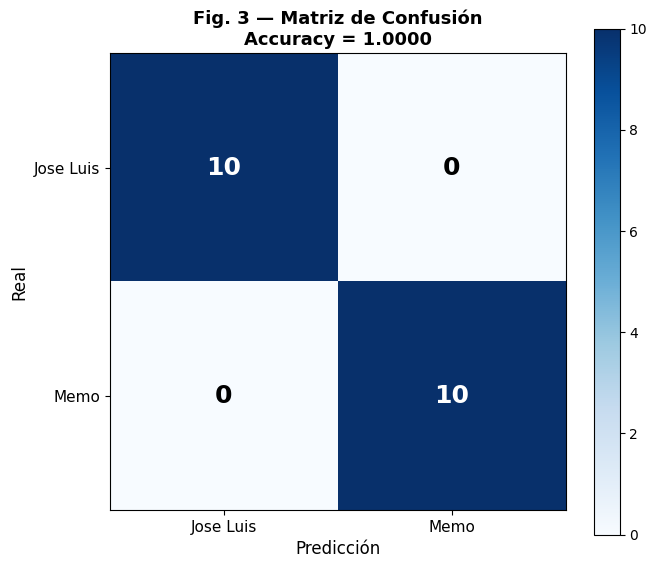

In [9]:
# Cell 10 — Evaluación y matriz de confusión
y_pred  = svm.predict(X_test)
nombres = [p.replace('_',' ').title() for p in le.classes_]

print('── Reporte de clasificación ──')
print(classification_report(y_test, y_pred, target_names=nombres))

cm  = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7,6))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im)
ax.set_xticks(range(len(nombres))); ax.set_xticklabels(nombres, fontsize=11)
ax.set_yticks(range(len(nombres))); ax.set_yticklabels(nombres, fontsize=11)
ax.set_xlabel('Predicción', fontsize=12)
ax.set_ylabel('Real',       fontsize=12)
for i in range(len(nombres)):
    for j in range(len(nombres)):
        ax.text(j, i, cm[i,j], ha='center', va='center', fontsize=18,
                fontweight='bold',
                color='white' if cm[i,j] > cm.max()/2 else 'black')
ax.set_title(f'Fig. 3 — Matriz de Confusión\nAccuracy = {acc:.4f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_matriz_confusion.png', dpi=130, bbox_inches='tight')
plt.show()

## Sección 4 — Reconocimiento en Tiempo Real

In [10]:
# Cell 11 — Reconocimiento en tiempo real
svm_rt    = joblib.load(f'{MODELOS_DIR}/svm_facial.pkl')
scaler_rt = joblib.load(f'{MODELOS_DIR}/scaler_facial.pkl')
le_rt     = joblib.load(f'{MODELOS_DIR}/label_encoder.pkl')

COLORES = {
    MI_NOMBRE:        (41, 182, 246),   # azul
    NOMBRE_COMPAÑERO: (231, 76,  60),   # rojo
    'desconocido':    (128, 128, 128),  # gris
}

historial = deque(maxlen=8)
cap       = cv2.VideoCapture(0)
print('🎥 Reconocimiento activo — presiona Q para salir')

while True:
    ret, frame = cap.read()
    if not ret: break

    gray    = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    rostros = face_cascade.detectMultiScale(
        gray, scaleFactor=1.1, minNeighbors=8, minSize=(80,80))

    for (x, y, w, h) in rostros:
        rostro = frame[y:y+h, x:x+w]
        try:
            resultado  = DeepFace.represent(img_path=rostro,
                model_name=MODELO_FACENET, enforce_detection=False)
            embedding  = np.array(resultado[0]['embedding']).reshape(1,-1)
            probs      = svm_rt.predict_proba(scaler_rt.transform(embedding))[0]
            clase_idx  = np.argmax(probs)
            confianza  = probs[clase_idx]

            historial.append((clase_idx, confianza))
            clases_hist   = [h[0] for h in historial]
            clase_estable = Counter(clases_hist).most_common(1)[0][0]
            conf_promedio = np.mean([h[1] for h in historial
                                     if h[0] == clase_estable])

            if conf_promedio >= UMBRAL_CONF:
                nombre = le_rt.inverse_transform([clase_estable])[0]
                label  = f'{nombre.replace("_"," ").title()}  {conf_promedio*100:.0f}%'
                color  = COLORES.get(nombre, (150,150,150))
            else:
                label  = f'Desconocido  {conf_promedio*100:.0f}%'
                color  = COLORES["desconocido"]

        except:
            label, color = 'Procesando...', (200,200,200)

        cv2.rectangle(frame, (x,y), (x+w,y+h), color, 2)
        cv2.rectangle(frame, (x, y-40), (x+w, y), color, -1)
        cv2.putText(frame, label, (x+6, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 2)

    cv2.putText(frame, 'Q = salir', (10, frame.shape[0]-15),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (200,200,200), 1)
    cv2.imshow('Reconocimiento Facial — Fase 4', frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
print('✅ Reconocimiento finalizado')

🎥 Reconocimiento activo — presiona Q para salir
✅ Reconocimiento finalizado


In [11]:
# Cell 12 — Captura automática de evidencias (30 segundos)
svm_rt    = joblib.load(f'{MODELOS_DIR}/svm_facial.pkl')
scaler_rt = joblib.load(f'{MODELOS_DIR}/scaler_facial.pkl')
le_rt     = joblib.load(f'{MODELOS_DIR}/label_encoder.pkl')

cap        = cv2.VideoCapture(0)
evidencias = []
inicio     = time.time()
ultima     = 0
INTERVALO  = 3
DURACION   = 30

print('📸 Capturando evidencias 30 segundos — muéstrate tú y tu compañero')

while time.time() - inicio < DURACION:
    ret, frame = cap.read()
    if not ret: break

    gray    = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    rostros = face_cascade.detectMultiScale(
        gray, scaleFactor=1.1, minNeighbors=8, minSize=(80,80))
    frame_ann = frame.copy()

    for (x, y, w, h) in rostros:
        rostro = frame[y:y+h, x:x+w]
        try:
            resultado  = DeepFace.represent(img_path=rostro,
                model_name=MODELO_FACENET, enforce_detection=False)
            embedding  = np.array(resultado[0]['embedding']).reshape(1,-1)
            probs      = svm_rt.predict_proba(scaler_rt.transform(embedding))[0]
            clase_idx  = np.argmax(probs)
            confianza  = probs[clase_idx]
            if confianza >= UMBRAL_CONF:
                nombre = le_rt.inverse_transform([clase_idx])[0]
                label  = f'{nombre.replace("_"," ").title()}  {confianza*100:.0f}%'
                color  = COLORES.get(nombre, (150,150,150))
            else:
                label, color = f'Desconocido  {confianza*100:.0f}%', COLORES['desconocido']
        except:
            label, color = 'Procesando...', (200,200,200)

        cv2.rectangle(frame_ann, (x,y), (x+w,y+h), color, 2)
        cv2.rectangle(frame_ann, (x, y-40), (x+w, y), color, -1)
        cv2.putText(frame_ann, label, (x+6, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 2)

    ahora = time.time() - inicio
    if ahora - ultima >= INTERVALO and len(rostros) > 0:
        ruta = f'evidencia_{len(evidencias)+1:02d}.jpg'
        cv2.imwrite(ruta, frame_ann)
        evidencias.append(ruta)
        ultima = ahora
        print(f'  📷 Evidencia {len(evidencias)} guardada')

    restante = int(DURACION - (time.time()-inicio))
    cv2.putText(frame_ann, f'Grabando... {restante}s',
                (10,30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,255), 2)
    cv2.imshow('Evidencias — Fase 4', frame_ann)
    if cv2.waitKey(1) & 0xFF == ord('q'): break

cap.release()
cv2.destroyAllWindows()
print(f'\n✅ {len(evidencias)} evidencias guardadas')

📸 Capturando evidencias 30 segundos — muéstrate tú y tu compañero
  📷 Evidencia 1 guardada
  📷 Evidencia 2 guardada
  📷 Evidencia 3 guardada

✅ 3 evidencias guardadas


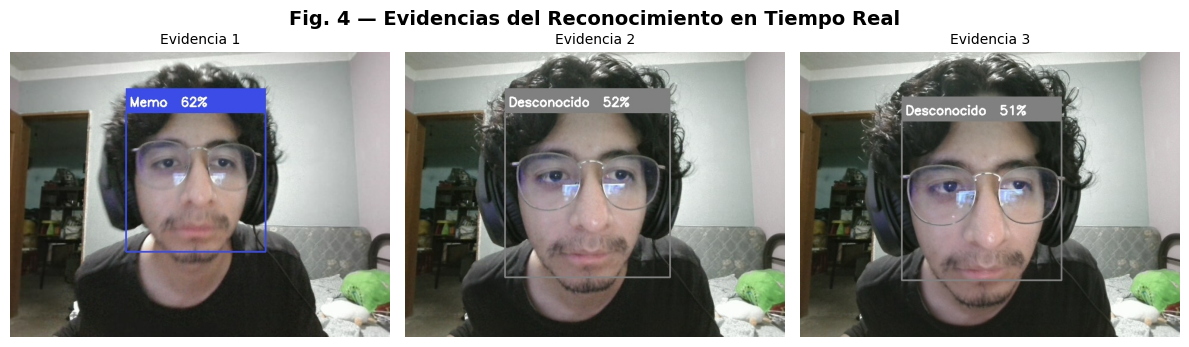

In [12]:
# Cell 13 — Mostrar evidencias
rutas_ev = sorted(Path('.').glob('evidencia_*.jpg'))
n        = len(rutas_ev)

if n == 0:
    print('⚠️  Sin evidencias — ejecuta Cell 12 primero')
else:
    cols = min(5, n)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*3.5))
    axes = np.array(axes).flatten() if n > 1 else [axes]
    fig.suptitle('Fig. 4 — Evidencias del Reconocimiento en Tiempo Real',
                 fontsize=14, fontweight='bold')
    for i, ruta in enumerate(rutas_ev):
        img = cv2.cvtColor(cv2.imread(str(ruta)), cv2.COLOR_BGR2RGB)
        axes[i].imshow(img)
        axes[i].set_title(f'Evidencia {i+1}', fontsize=10)
        axes[i].axis('off')
    for j in range(i+1, len(axes)): axes[j].axis('off')
    plt.tight_layout()
    plt.savefig('fig4_evidencias.png', dpi=130, bbox_inches='tight')
    plt.show()

In [13]:
# Cell 14 — Resumen final
print('══════════════════════════════════════════════════')
print('  RESUMEN — Fase 4: Reconocimiento Facial')
print('══════════════════════════════════════════════════')
print(f'  Arquitectura  : FaceNet (embeddings 128D) + SVM RBF')
print(f'  Personas      : {[p.replace("_"," ").title() for p in PERSONAS]}')
print(f'  Dataset       : {len(X_raw)} fotos ({len(X_raw)//len(PERSONAS)} por persona)')
print(f'  Dim. embedding: {X_raw.shape[1]} valores por rostro')
print(f'  Precisión SVM : {acc:.4f} ({acc*100:.2f}%)')
print(f'  Umbral conf   : {UMBRAL_CONF} → bajo ese valor = Desconocido')
print(f'  Suavizado     : ventana de 8 frames')
print('══════════════════════════════════════════════════')
print()
archivos = ['fig1_dataset.png','fig2_embeddings_pca.png',
            'fig3_matriz_confusion.png','fig4_evidencias.png']
for f in archivos:
    print(f'  {"✅" if Path(f).exists() else "⚠️ pendiente"}  {f}')

══════════════════════════════════════════════════
  RESUMEN — Fase 4: Reconocimiento Facial
══════════════════════════════════════════════════
  Arquitectura  : FaceNet (embeddings 128D) + SVM RBF
  Personas      : ['Jose Luis', 'Memo']
  Dataset       : 100 fotos (50 por persona)
  Dim. embedding: 128 valores por rostro
  Precisión SVM : 1.0000 (100.00%)
  Umbral conf   : 0.55 → bajo ese valor = Desconocido
  Suavizado     : ventana de 8 frames
══════════════════════════════════════════════════

  ✅  fig1_dataset.png
  ✅  fig2_embeddings_pca.png
  ✅  fig3_matriz_confusion.png
  ✅  fig4_evidencias.png


In [ ]:
# Cell 15 — Exportar a HTML
!jupyter nbconvert --to html Fase4_Reconocimiento_Facial.ipynb
print('✅ HTML generado: Fase4_Reconocimiento_Facial.html')

This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--execute
    Execute the notebook prior to export.
    Equivalent to: [--ExecutePr

[NbConvertApp] WARNING | pattern 'Fase4_Reconocimiento_Facial.ipynb' matched no files
